In [54]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50, VGG16, InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
DATA_DIR = Path("../data")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

..\data\train
..\data\val
..\data\test


In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10

In [5]:
# Image Generator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


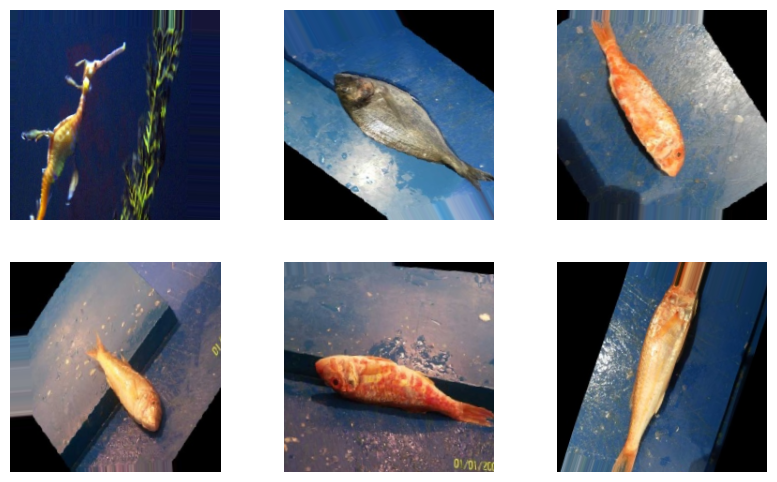

In [6]:
# Showing sample images

images, labels = next(train_generator)

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [7]:
# Building baseline CNN

num_classes = train_generator.num_classes

model = models.Sequential([
    
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,379 (42.61 MB)

 Trainable params: 11,170,379 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Training Model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.3002 - loss: 1.9820 - val_accuracy: 0.5375 - val_loss: 1.4118
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.4551 - loss: 1.4614 - val_accuracy: 0.5082 - val_loss: 1.2774
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.5433 - loss: 1.2335 - val_accuracy: 0.7564 - val_loss: 0.7783
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 193s 988ms/step - accuracy: 0.6125 - loss: 1.0651 - val_accuracy: 0.7912 - val_loss: 0.7239
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.6671 - loss: 0.9223 - val_accuracy: 0.8654 - val_loss: 0.5102
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 190s 973ms/step - accuracy: 0.7041 - loss: 0.8136 - val_accuracy: 0.8489 - val_loss: 0.4539
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 184s 941ms/step - accuracy: 0.7438 - loss: 0.7296 - val_accuracy: 0.8883 - val_loss: 0.3791
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 180s 923ms/step - accuracy: 0.7677 - loss: 0.638

In [9]:
model.save("../models/baseline_cnn.h5")

print("Model saved")

Model saved


In [10]:
# checking accuracy

print("Final Train Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Train Accuracy: 0.7958232760429382
Final Validation Accuracy: 0.8681318759918213


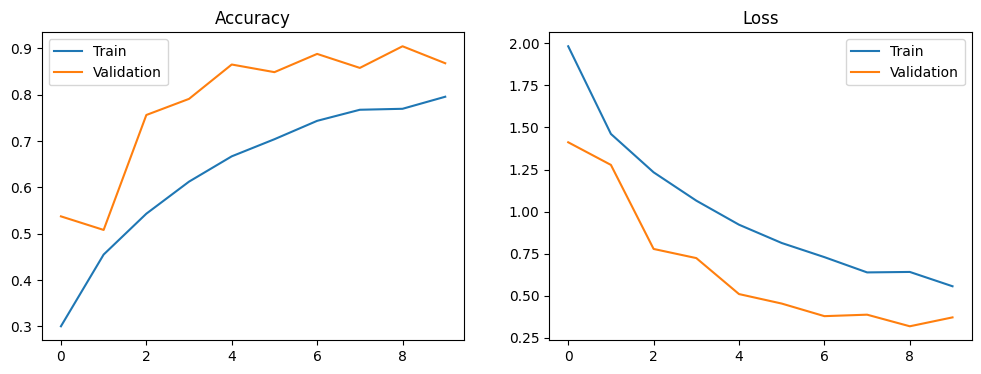

In [11]:
# Training curves

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step
                                  precision    recall  f1-score   support

                     animal fish       0.97      0.99      0.98       520
                animal fish bass       0.00      0.00      0.00        13
   fish sea_food black_sea_sprat       0.83      0.99      0.91       298
   fish sea_food gilt_head_bream       0.99      0.47      0.64       305
   fish sea_food hourse_mackerel       0.82      0.96      0.89       286
        fish sea_food red_mullet       0.98      0.98      0.98       291
     fish sea_food red_sea_bream       0.75      0.83      0.79       273
          fish sea_food sea_bass       0.89      0.88      0.88       327
            fish sea_food shrimp       0.79      1.00      0.88       289
fish sea_food striped_red_mullet       0.97      0.58      0.73       293
             fish sea_food trout       0.80      1.00      0.89       292

                        accuracy                           0.87   

c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

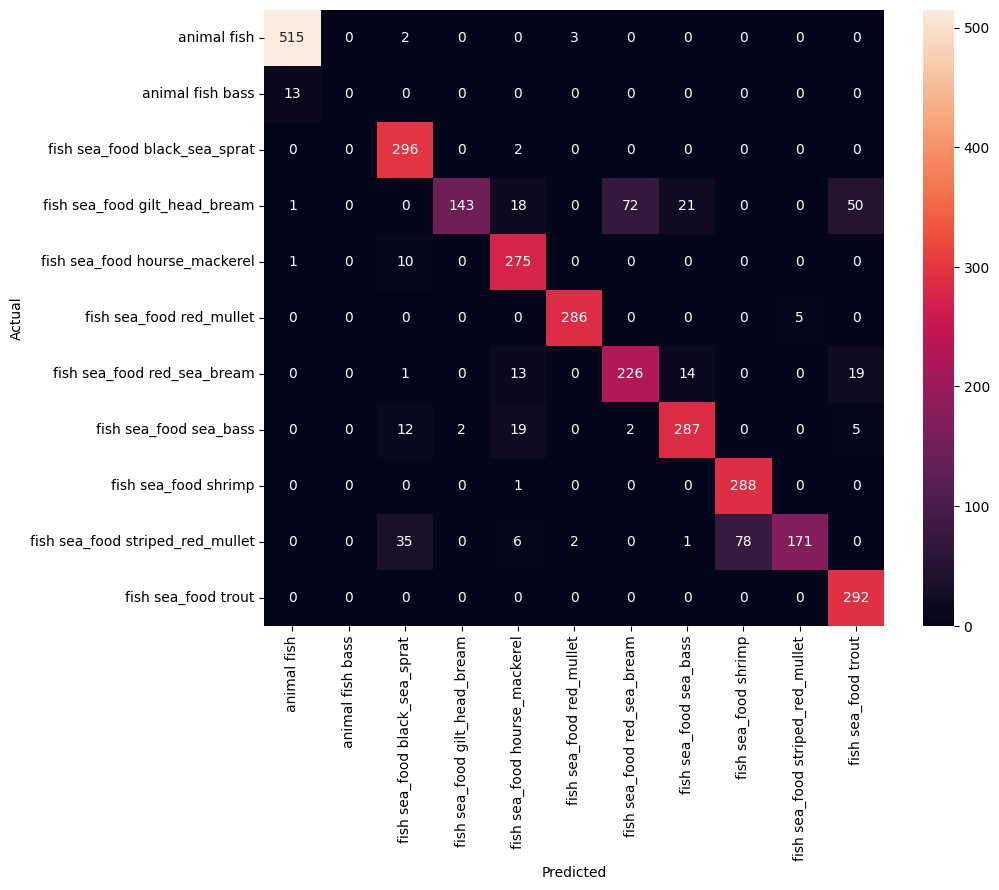

In [12]:
# Evaluation

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions,axis=1)
y_true = test_generator.classes

class_names = list(train_generator.class_indices.keys())

print(classification_report(y_true,y_pred,target_names=class_names))

cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# Building Transfer model

def build_transfer_model(base_model, num_classes):

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Training MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model = build_transfer_model(base_model, num_classes)

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 123s 616ms/step - accuracy: 0.7907 - loss: 0.6632 - val_accuracy: 0.9524 - val_loss: 0.1412
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 143s 732ms/step - accuracy: 0.9327 - loss: 0.2180 - val_accuracy: 0.9625 - val_loss: 0.1031
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 134s 685ms/step - accuracy: 0.9497 - loss: 0.1608 - val_accuracy: 0.9707 - val_loss: 0.0732
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 130s 666ms/step - accuracy: 0.9600 - loss: 0.1251 - val_accuracy: 0.9744 - val_loss: 0.0649
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 135s 689ms/step - accuracy: 0.9682 - loss: 0.0970 - val_accuracy: 0.9890 - val_loss: 0.0371


MobileNet model saved


In [15]:
# Fine-Tune MobileNetV2

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_mobilenet_ft = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)


mobilenet_model.save("../models/mobilenet_model.h5")
print("MobileNet model saved")

Epoch 1/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 148s 732ms/step - accuracy: 0.6397 - loss: 2.0798 - val_accuracy: 0.9844 - val_loss: 0.0448
Epoch 2/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 158s 812ms/step - accuracy: 0.9436 - loss: 0.1785 - val_accuracy: 0.9863 - val_loss: 0.0406
Epoch 3/3
195/195 ━━━━━━━━━━━━━━━━━━━━ 150s 766ms/step - accuracy: 0.9589 - loss: 0.1288 - val_accuracy: 0.9872 - val_loss: 0.0376


MobileNet model saved


In [16]:
print(history_mobilenet_ft.history['val_accuracy'][-1])

0.9871794581413269


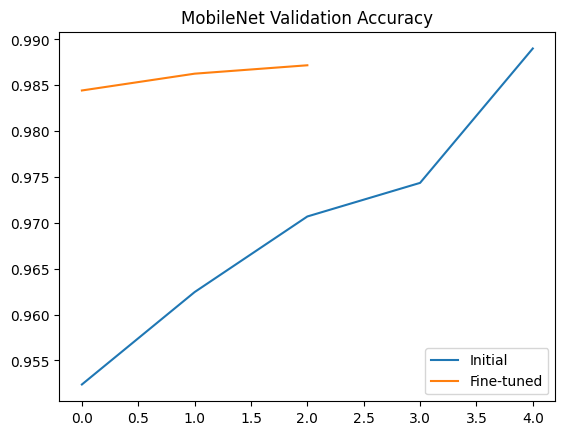

In [17]:
# Plotting MobileNet Results

plt.plot(history_mobilenet.history["val_accuracy"], label="Initial")
plt.plot(history_mobilenet_ft.history["val_accuracy"], label="Fine-tuned")

plt.title("MobileNet Validation Accuracy")
plt.legend()
plt.show()

In [18]:
# Model results table

results = pd.DataFrame({
    "Model": ["Baseline CNN", "MobileNetV2"],
    "Validation Accuracy": [0.8681, 0.9872]
})

results

,Model,Validation Accuracy
0,Baseline CNN,0.8681
1,MobileNetV2,0.9872


In [19]:
# Training EfficientNetB0

eff_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

eff_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

eff_train_generator = eff_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

eff_val_generator = eff_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.


In [21]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

efficientnet_model = Model(inputs=base_model.input, outputs=outputs)

efficientnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,958 (16.08 MB)

 Trainable params: 165,387 (646.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
# Training EfficientNet

history_eff = efficientnet_model.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=5
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 170s 836ms/step - accuracy: 0.6744 - loss: 0.9981 - val_accuracy: 0.9194 - val_loss: 0.3134
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 174s 890ms/step - accuracy: 0.8484 - loss: 0.4768 - val_accuracy: 0.9377 - val_loss: 0.2172
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 175s 898ms/step - accuracy: 0.8856 - loss: 0.3631 - val_accuracy: 0.9570 - val_loss: 0.1680
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 175s 898ms/step - accuracy: 0.9035 - loss: 0.2999 - val_accuracy: 0.9670 - val_loss: 0.1185
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 167s 854ms/step - accuracy: 0.9078 - loss: 0.2810 - val_accuracy: 0.9679 - val_loss: 0.1085


In [23]:
efficientnet_model.save("../models/efficientnet_model.h5")

In [25]:
results = pd.DataFrame({
    "Model": ["Baseline CNN", "MobileNetV2", "EfficientNetB0"],
    "Validation Accuracy": [0.8681, 0.9872, 0.9679]
})

results

,Model,Validation Accuracy
0,Baseline CNN,0.8681
1,MobileNetV2,0.9872
2,EfficientNetB0,0.9679


In [31]:
# ResNet50 Training

res_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

res_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

res_train_generator = res_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

res_val_generator = res_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.


In [32]:
# Building Model ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = build_transfer_model(base_model, num_classes)

history_resnet = resnet_model.fit(
    res_train_generator,
    validation_data=res_val_generator,
    epochs=5
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.8132 - loss: 0.5953 - val_accuracy: 0.9853 - val_loss: 0.0607
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.9459 - loss: 0.1774 - val_accuracy: 0.9881 - val_loss: 0.0395
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.9560 - loss: 0.1317 - val_accuracy: 0.9890 - val_loss: 0.0342
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.9645 - loss: 0.1078 - val_accuracy: 0.9908 - val_loss: 0.0235
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.9679 - loss: 0.0971 - val_accuracy: 0.9918 - val_loss: 0.0228


In [33]:
resnet_model.save("../models/resnet50_model.h5")

In [34]:
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "EfficientNetB0",
        "ResNet50"
    ],
    "Validation Accuracy": [
        0.8681,
        0.9872,
        0.9679,
        0.9918
    ]
})

results

,Model,Validation Accuracy
0,Baseline CNN,0.8681
1,MobileNetV2,0.9872
2,EfficientNetB0,0.9679
3,ResNet50,0.9918


In [40]:
# Training VGG16

vgg_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

vgg_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

vgg_train_generator = vgg_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

vgg_val_generator = vgg_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.


In [41]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

vgg_model = build_transfer_model(base_model, num_classes)

history_vgg = vgg_model.fit(
    vgg_train_generator,
    validation_data=vgg_val_generator,
    epochs=5
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 662s 3s/step - accuracy: 0.6271 - loss: 1.4107 - val_accuracy: 0.9295 - val_loss: 0.2418
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 798s 4s/step - accuracy: 0.8580 - loss: 0.4193 - val_accuracy: 0.9753 - val_loss: 0.0907
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 761s 4s/step - accuracy: 0.9094 - loss: 0.2656 - val_accuracy: 0.9826 - val_loss: 0.0627
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 745s 4s/step - accuracy: 0.9253 - loss: 0.2215 - val_accuracy: 0.9835 - val_loss: 0.0615
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 852s 4s/step - accuracy: 0.9372 - loss: 0.1857 - val_accuracy: 0.9899 - val_loss: 0.0417


In [42]:
vgg_model.save("../models/vgg16_model.h5")

In [43]:
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "EfficientNetB0",
        "ResNet50",
        "VGG16"
    ],
    "Validation Accuracy": [
        0.8681,
        0.9872,
        0.9679,
        0.9918,
        0.9899
    ]
})

results.sort_values(by="Validation Accuracy", ascending=False)

,Model,Validation Accuracy
3,ResNet50,0.9918
4,VGG16,0.9899
1,MobileNetV2,0.9872
2,EfficientNetB0,0.9679
0,Baseline CNN,0.8681


In [46]:
# InceptionV3 training

inc_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

inc_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

inc_train_generator = inc_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(299,299),
    batch_size=32,
    class_mode="categorical"
)

inc_val_generator = inc_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(299,299),
    batch_size=32,
    class_mode="categorical"
)

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.


In [47]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299,299,3)
)

inception_model = build_transfer_model(base_model, num_classes)

history_inc = inception_model.fit(
    inc_train_generator,
    validation_data=inc_val_generator,
    epochs=5
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.1655 - loss: 3.3906 - val_accuracy: 0.1694 - val_loss: 2.1802
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.1767 - loss: 2.2027 - val_accuracy: 0.2216 - val_loss: 2.1288
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.1859 - loss: 2.2092 - val_accuracy: 0.2115 - val_loss: 2.1271
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.2006 - loss: 2.1616 - val_accuracy: 0.2234 - val_loss: 2.0499
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.2076 - loss: 2.1413 - val_accuracy: 0.2234 - val_loss: 2.1452


In [48]:
inception_model.save("../models/inceptionv3_model.h5")

In [49]:
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "EfficientNetB0",
        "ResNet50",
        "VGG16",
        "InceptionV3"
    ],
    "Validation Accuracy": [
        0.8681,
        0.9872,
        0.9679,
        0.9918,
        0.9899,
        0.2234
    ]
})

results.sort_values(by="Validation Accuracy", ascending=False)

,Model,Validation Accuracy
3,ResNet50,0.9918
4,VGG16,0.9899
1,MobileNetV2,0.9872
2,EfficientNetB0,0.9679
0,Baseline CNN,0.8681
5,InceptionV3,0.2234


In [50]:
# finding the best result

best_row = results.loc[results["Validation Accuracy"].idxmax()]

best_model_name = best_row["Model"]
best_accuracy = best_row["Validation Accuracy"]

print("Best Model:", best_model_name)
print("Validation Accuracy:", best_accuracy)

Best Model: ResNet50
Validation Accuracy: 0.9918


In [51]:
# Creating a dictionary for models

model_dict = {
    "Baseline CNN": model,
    "MobileNetV2": mobilenet_model,
    "EfficientNetB0": efficientnet_model,
    "ResNet50": resnet_model,
    "VGG16": vgg_model,
    "InceptionV3": inception_model
}

In [ ]:
# The best model

best_model = model_dict[best_model_name]

print("Selected model for final evaluation:", best_model_name)

Selected model for final evaluation: ResNet50


In [53]:
# Predicting on Test Dataset

predictions = best_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_names = list(train_generator.class_indices.keys())

100/100 ━━━━━━━━━━━━━━━━━━━━ 90s 877ms/step


In [55]:
# Finding classification report

print(classification_report(y_true, y_pred, target_names=class_names))

                                  precision    recall  f1-score   support

                     animal fish       0.16      1.00      0.28       520
                animal fish bass       0.00      0.00      0.00        13
   fish sea_food black_sea_sprat       0.00      0.00      0.00       298
   fish sea_food gilt_head_bream       0.00      0.00      0.00       305
   fish sea_food hourse_mackerel       0.00      0.00      0.00       286
        fish sea_food red_mullet       0.00      0.00      0.00       291
     fish sea_food red_sea_bream       0.00      0.00      0.00       273
          fish sea_food sea_bass       0.00      0.00      0.00       327
            fish sea_food shrimp       0.00      0.00      0.00       289
fish sea_food striped_red_mullet       0.00      0.00      0.00       293
             fish sea_food trout       0.00      0.00      0.00       292

                        accuracy                           0.16      3187
                       macro avg    

c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rspmp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

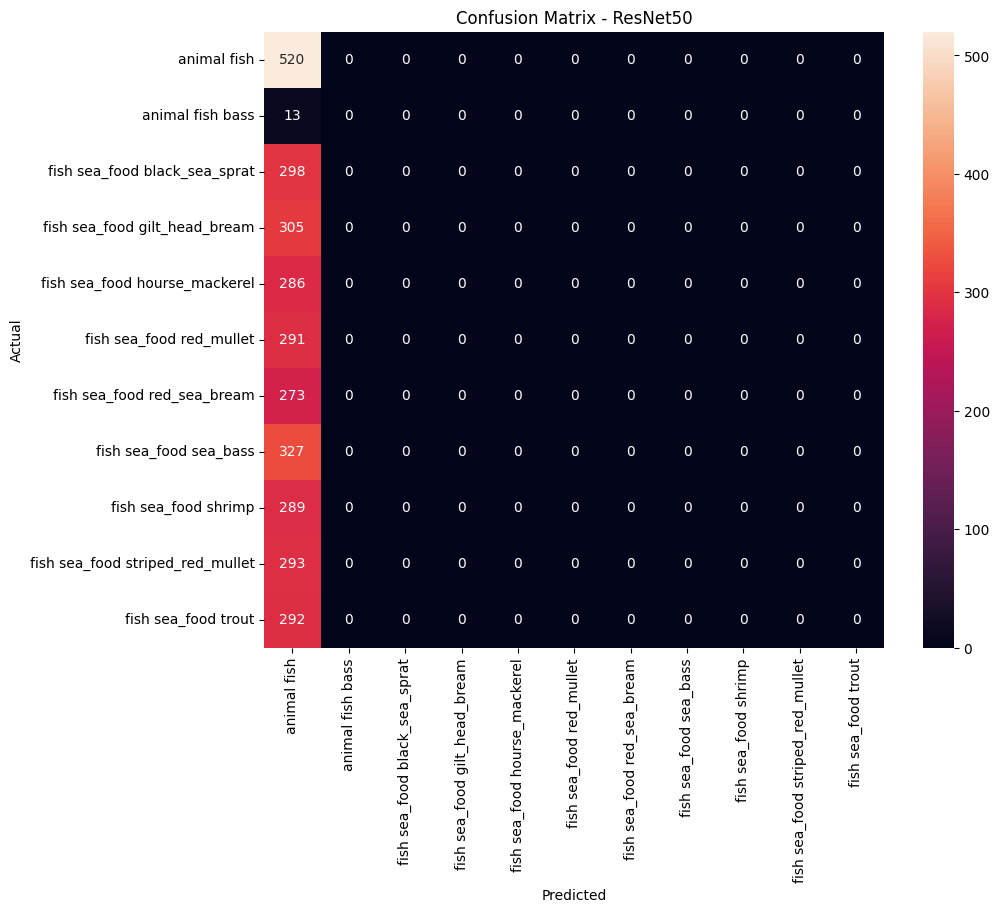

In [56]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [57]:
best_model.save("../models/best_fish_classifier.h5")

print("Best model saved successfully!")

Best model saved successfully!
